Countries loaded: 218
World population 2023: 8.05B


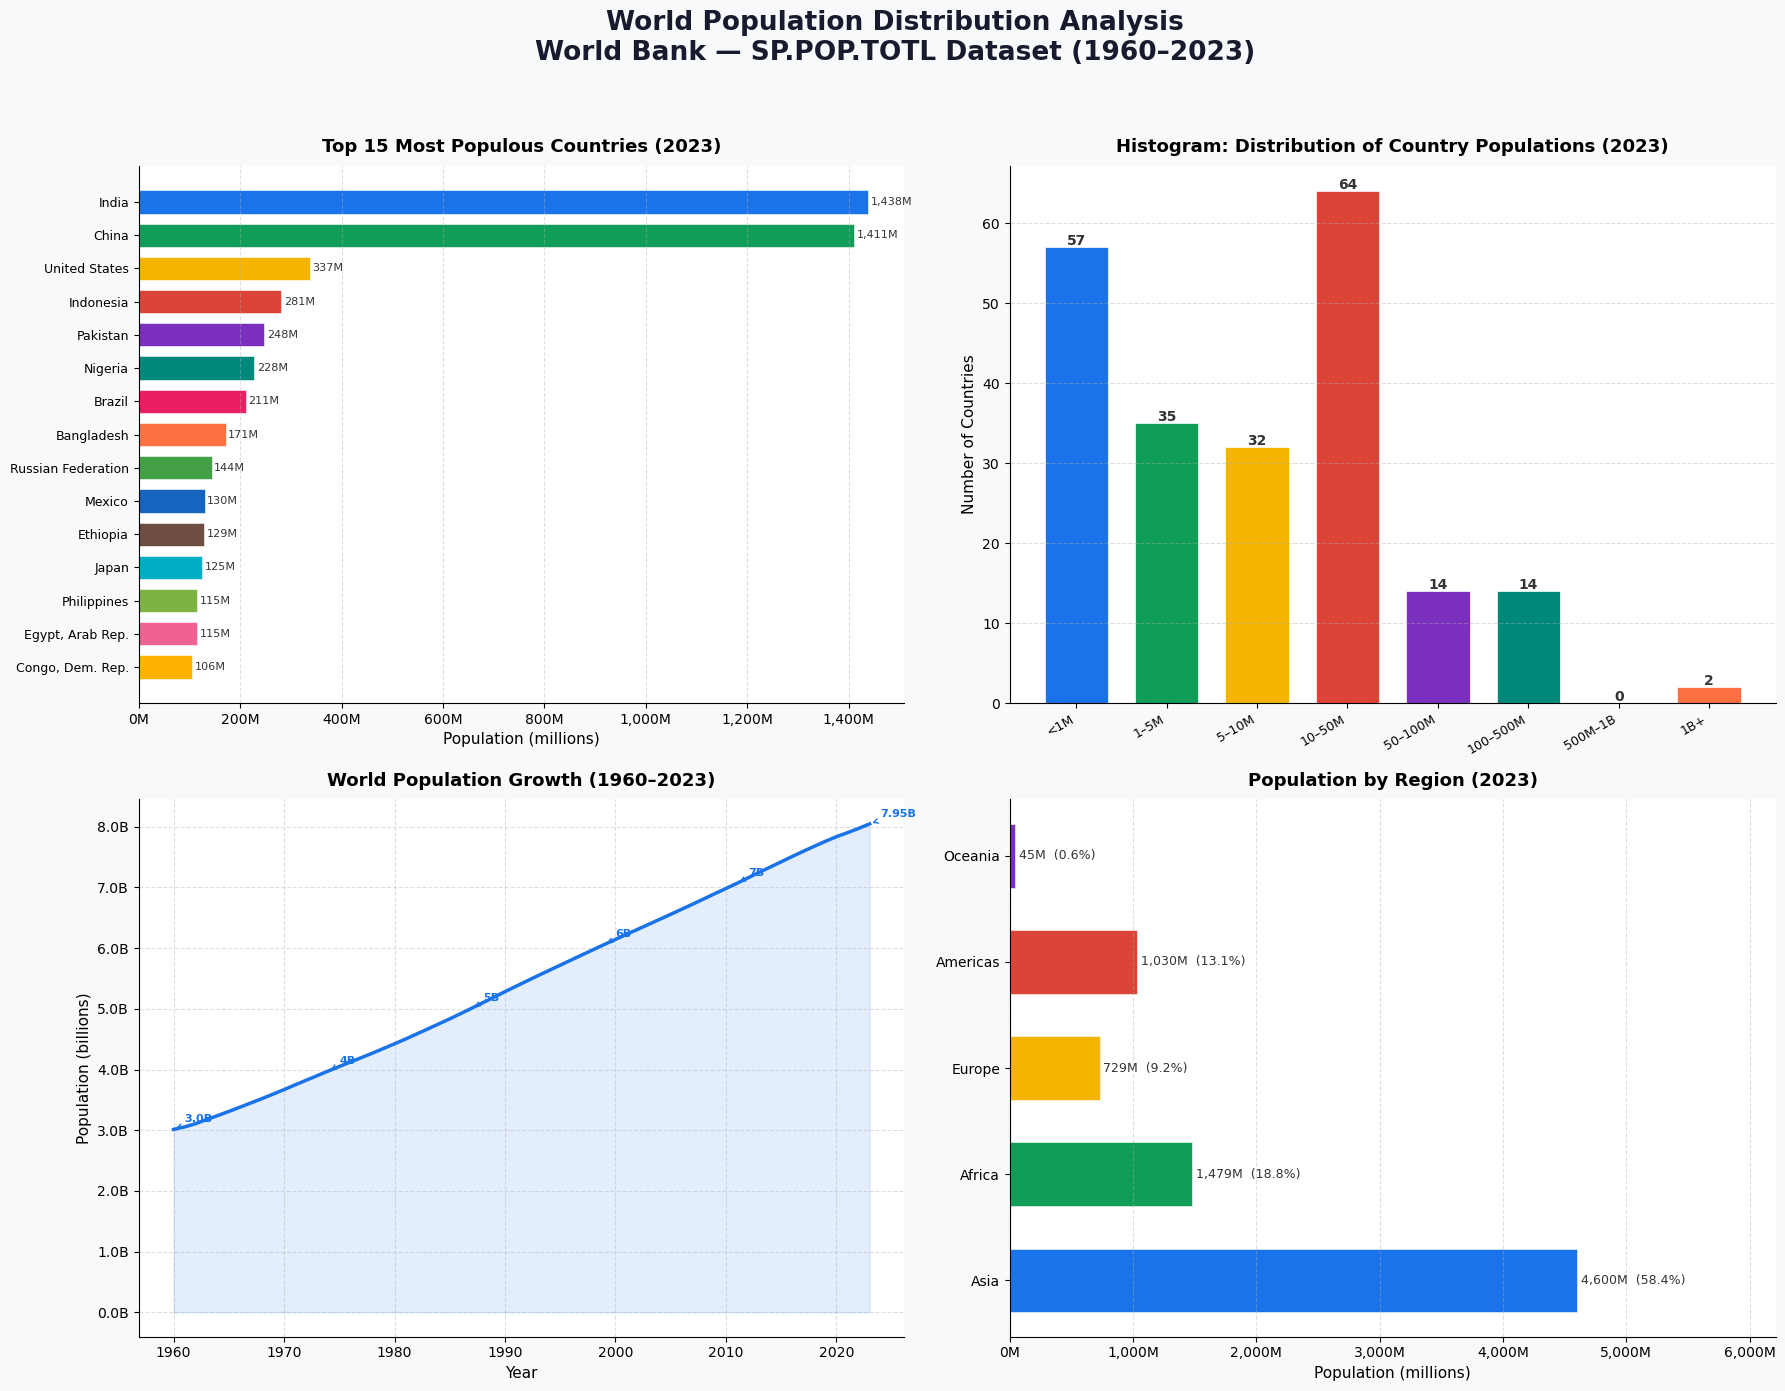

Saved: world_population_analysis.png


In [17]:
# ============================================================
# PRODIGY INFOTECH — Data Science Internship
# Task 01: Population Distribution Visualization
# Dataset: World Bank SP.POP.TOTL (API_SP.POP.TOTL_DS2_en_csv)
# Author: Edmond Wehbe
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import re

# ── 1. LOAD DATA ─────────────────────────────────────────────
file_path = r"C:\Users\Lenovo\OneDrive\Desktop\task1-prodigy\API_SP.POP.TOTL_DS2_en_csv_v2_38144.csv.csv"
df = pd.read_csv(file_path, skiprows=4)

# ── 2. FILTER TO INDIVIDUAL COUNTRIES ONLY ───────────────────
aggregate_codes = {
    'WLD','EAS','EAP','ECS','ECA','LCN','LAC','MEA','MNA','NAC','SAS','SSF','SSA',
    'AFE','AFW','ARB','CEB','EAR','EMU','EUU','FCS','HIC','HPC','IBD','IBT','IDA',
    'IDB','IDX','INX','LDC','LIC','LMC','LMY','LTE','MIC','OSS','PRE','PSS','PST',
    'TEA','TEC','TLA','TMN','TSA','TSS','UMC','XZN'
}

def is_country(row):
    code = str(row['Country Code'])
    name = str(row['Country Name'])
    if code in aggregate_codes:
        return False
    if not re.match(r'^[A-Z]{3}$', code):
        return False
    exclude = ['income','Income','region','Region','Sub-Saharan','Arab World',
               'Euro area','OECD','IDA','IBRD','dividend','demographic','Fragile',
               'Heavily','Least ','Low-','High-','Upper middle','Lower middle',
               'Small states','Early-','Late-','Pre-']
    return not any(ex in name for ex in exclude)

countries_df = df[df.apply(is_country, axis=1)].copy()

# Convert all year columns to numeric
for y in [str(yr) for yr in range(1960, 2024)]:
    countries_df[y] = pd.to_numeric(countries_df[y], errors='coerce')

countries_df['pop2023']     = countries_df['2023']
countries_df               = countries_df.dropna(subset=['pop2023'])
countries_df['pop_millions'] = countries_df['pop2023'] / 1_000_000

print(f"Countries loaded: {len(countries_df)}")
print(f"World population 2023: {countries_df['pop2023'].sum()/1e9:.2f}B")

# ── 3. DERIVED DATA ──────────────────────────────────────────
# Top 15
top15 = countries_df.nlargest(15, 'pop2023')[['Country Name','pop_millions']].reset_index(drop=True)

# Histogram bins
bins   = [0, 1, 5, 10, 50, 100, 500, 1000, 1500]
labels = ['<1M','1–5M','5–10M','10–50M','50–100M','100–500M','500M–1B','1B+']
countries_df['bin'] = pd.cut(countries_df['pop_millions'], bins=bins, labels=labels, right=True)
bin_counts = countries_df['bin'].value_counts().reindex(labels)

# World total by year
years     = [str(y) for y in range(1960, 2024)]
world_pop = [countries_df[y].sum() / 1e9 for y in years]

# Regional totals
region_map = {
    'Asia':     ['China','India','Indonesia','Pakistan','Bangladesh','Japan','Philippines',
                 'Vietnam','Iran, Islamic Rep.','Turkiye','Thailand','Myanmar','Korea, Rep.',
                 'Iraq','Saudi Arabia','Uzbekistan','Malaysia','Yemen, Rep.','Nepal',
                 'Sri Lanka','Kazakhstan','Syrian Arab Republic','Cambodia','Jordan',
                 'Azerbaijan','United Arab Emirates','Tajikistan','Israel','Lao PDR',
                 'Singapore','Lebanon','Kyrgyz Republic','Turkmenistan','Afghanistan',
                 'Mongolia','Armenia','Qatar','Bahrain','Timor-Leste','Cyprus','Bhutan',
                 'Maldives','Brunei Darussalam','Oman','Kuwait','Georgia'],
    'Africa':   ['Nigeria','Ethiopia','Egypt, Arab Rep.','Congo, Dem. Rep.','Tanzania',
                 'Kenya','South Africa','Uganda','Algeria','Sudan','Morocco','Angola',
                 'Ghana','Mozambique','Madagascar','Cameroon',"Cote d'Ivoire",'Niger',
                 'Burkina Faso','Mali','Malawi','Zambia','Senegal','Chad','Somalia',
                 'Zimbabwe','Guinea','Rwanda','Benin','Burundi','Tunisia','South Sudan',
                 'Togo','Sierra Leone','Libya','Congo, Rep.','Liberia',
                 'Central African Republic','Eritrea','Mauritania','Gambia, The',
                 'Botswana','Namibia','Gabon','Lesotho','Guinea-Bissau',
                 'Equatorial Guinea','Mauritius','Eswatini','Djibouti','Comoros',
                 'Cabo Verde','Sao Tome and Principe','Seychelles'],
    'Europe':   ['Germany','France','United Kingdom','Italy','Spain','Ukraine','Poland',
                 'Romania','Netherlands','Belgium','Czech Republic','Greece','Portugal',
                 'Sweden','Hungary','Belarus','Austria','Switzerland','Serbia','Bulgaria',
                 'Denmark','Finland','Slovak Republic','Norway','Ireland','Croatia',
                 'Bosnia and Herzegovina','Albania','Lithuania','North Macedonia',
                 'Slovenia','Latvia','Estonia','Montenegro','Luxembourg','Malta',
                 'Iceland','Andorra','Monaco','Liechtenstein','San Marino','Moldova',
                 'Russian Federation'],
    'Americas': ['United States','Brazil','Mexico','Colombia','Argentina','Canada',
                 'Peru','Venezuela, RB','Chile','Ecuador','Guatemala','Cuba','Bolivia',
                 'Dominican Republic','Haiti','Honduras','Paraguay','El Salvador',
                 'Nicaragua','Costa Rica','Panama','Uruguay','Jamaica',
                 'Trinidad and Tobago','Guyana','Suriname','Belize','Barbados',
                 'St. Lucia','Grenada','Antigua and Barbuda',
                 'St. Vincent and the Grenadines','Dominica','St. Kitts and Nevis'],
    'Oceania':  ['Australia','Papua New Guinea','New Zealand','Fiji','Solomon Islands',
                 'Vanuatu','Samoa','Kiribati','Tonga','Micronesia, Fed. Sts.',
                 'Palau','Marshall Islands','Tuvalu','Nauru'],
}
region_pop = {
    reg: countries_df[countries_df['Country Name'].isin(ctries)]['pop_millions'].sum()
    for reg, ctries in region_map.items()
}

# ── 4. PLOT ───────────────────────────────────────────────────
BLUE   = '#1A73E8'; GREEN  = '#0F9D58'
ORANGE = '#F4B400'; RED    = '#DB4437'; PURPLE = '#7B2FBE'
COLORS_TOP = [BLUE,GREEN,ORANGE,RED,PURPLE,'#00897B','#E91E63',
              '#FF7043','#43A047','#1565C0','#6D4C41','#00ACC1',
              '#7CB342','#F06292','#FFB300']

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#F8F9FA')
plt.suptitle('World Population Distribution Analysis\nWorld Bank — SP.POP.TOTL Dataset (1960–2023)',
             fontsize=19, fontweight='bold', y=0.99, color='#1A1A2E')

# — Chart 1: Top 15 countries —
ax1 = fig.add_subplot(2, 2, 1)
ax1.set_facecolor('#FFFFFF')
bars = ax1.barh(top15['Country Name'][::-1], top15['pop_millions'][::-1],
                color=COLORS_TOP[::-1], edgecolor='white', linewidth=0.4, height=0.7)
ax1.set_xlabel('Population (millions)', fontsize=11)
ax1.set_title('Top 15 Most Populous Countries (2023)', fontsize=13, fontweight='bold', pad=10)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))
ax1.tick_params(axis='y', labelsize=9)
ax1.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, top15['pop_millions'][::-1]):
    ax1.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
             f'{val:,.0f}M', va='center', fontsize=8, color='#333')
ax1.grid(axis='x', linestyle='--', alpha=0.4)

# — Chart 2: Histogram —
ax2 = fig.add_subplot(2, 2, 2)
ax2.set_facecolor('#FFFFFF')
bar_colors = [BLUE,GREEN,ORANGE,RED,PURPLE,'#00897B','#E91E63','#FF7043']
rects = ax2.bar(range(len(labels)), bin_counts.values,
                color=bar_colors, edgecolor='white', linewidth=0.5, width=0.7)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Number of Countries', fontsize=11)
ax2.set_title('Histogram: Distribution of Country Populations (2023)',
              fontsize=13, fontweight='bold', pad=10)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
for rect, val in zip(rects, bin_counts.values):
    ax2.text(rect.get_x()+rect.get_width()/2, rect.get_height()+0.3,
             str(int(val)), ha='center', fontsize=10, fontweight='bold', color='#333')

# — Chart 3: Growth line chart —
ax3 = fig.add_subplot(2, 2, 3)
ax3.set_facecolor('#FFFFFF')
year_ints = list(range(1960, 2024))
ax3.fill_between(year_ints, world_pop, alpha=0.12, color=BLUE)
ax3.plot(year_ints, world_pop, color=BLUE, linewidth=2.5)
ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('Population (billions)', fontsize=11)
ax3.set_title('World Population Growth (1960–2023)', fontsize=13, fontweight='bold', pad=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))
ax3.spines[['top','right']].set_visible(False)
ax3.grid(linestyle='--', alpha=0.4)
for yr, lbl in [(1960,'3.0B'),(1974,'4B'),(1987,'5B'),(1999,'6B'),(2011,'7B'),(2023,'7.95B')]:
    idx = yr - 1960
    ax3.annotate(lbl, xy=(yr, world_pop[idx]), xytext=(yr+1, world_pop[idx]+0.12),
                 fontsize=8, color=BLUE, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=BLUE, lw=1))

# — Chart 4: Regional populations —
ax4 = fig.add_subplot(2, 2, 4)
ax4.set_facecolor('#FFFFFF')
reg_names = list(region_pop.keys())
reg_vals  = [region_pop[r] for r in reg_names]
total_reg = sum(reg_vals)
h_bars = ax4.barh(reg_names, reg_vals,
                  color=[BLUE,GREEN,ORANGE,RED,PURPLE],
                  edgecolor='white', linewidth=0.4, height=0.6)
ax4.set_xlabel('Population (millions)', fontsize=11)
ax4.set_title('Population by Region (2023)', fontsize=13, fontweight='bold', pad=10)
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))
ax4.spines[['top','right']].set_visible(False)
ax4.grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(h_bars, reg_vals):
    pct = val / total_reg * 100
    ax4.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
             f'{val:,.0f}M  ({pct:.1f}%)', va='center', fontsize=9, color='#333')
ax4.set_xlim(0, max(reg_vals) * 1.35)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('world_population_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Saved: world_population_analysis.png")